# Notebook 29 — Full-protocol Level 1–3 audit for DC–AC charging

## Objective

This notebook audits DC–AC charging under a full CC–CV protocol using a three-level validation structure.

### Level 1 — Operational protocol effectiveness

Test whether DC–AC charging reaches the same net charge state $Q_\mathrm{net}$ / SOC earlier than the corresponding DC reference under the same peak-current and voltage constraints.

### Level 2 — Common-CC current-geometry separation

In the shared prescribed-current CC region before either protocol reaches 4.2 V, decompose:

$$
\Delta t_\mathrm{model}(Q)
=
\Delta t_\mathrm{geom}(Q)
+
\Delta t_\mathrm{resid}(Q)
$$

where $\Delta t_\mathrm{geom}(Q)$ is computed only from the imposed current waveform.

### Level 3 — Boundary/CV contribution audit

After the 4.2 V boundary is reached by one branch, analyze whether the remaining full-protocol time gain is preserved, amplified, or consumed through boundary timing, AC-off transition, and CV feedback trajectory.

---

## Scope

This notebook does not claim universal electrochemical acceleration. It separates:

- current-waveform first-passage geometry,
- voltage-boundary timing,
- control-state transition,
- CV feedback trajectory,
- possible non-geometric electrochemical residual.

The full-protocol time difference is interpreted as a layered quantity:

$$
\Delta t_\mathrm{full}(Q)
=
\Delta t_\mathrm{CC,geom}(Q)
+
\Delta t_\mathrm{boundary/CV}(Q)
+
\Delta t_\mathrm{possible\,resid}(Q)
$$

The prescribed-current CC region is treated separately from the voltage-limited and CV-controlled regions.

---

## Initial parameter sets

The first audit uses parameter sets previously validated in the Day18B CC-only residual null baseline:

- Chen2020
- Ecker2015
- ORegan2022

These parameter sets are used first because their prescribed-current CC-only behavior already showed:

$$
\Delta t_\mathrm{model}(Q) \approx \Delta t_\mathrm{geom}(Q)
$$

and therefore:

$$
\Delta t_\mathrm{resid}(Q) \approx 0
$$

within numerical resolution.

---

## Initial conditions

The first audit starts with selected DC–AC protocols satisfying:

$$
I_\mathrm{DC} + I_\mathrm{AC} \leq 1C
$$

and uses the charge-first convention aligned with the experimental NGU201 ARB waveform:

$$
I_\mathrm{py}(t) = -I_\mathrm{DC} - I_\mathrm{AC}\sin(2\pi f t)
$$

where PyBaMM uses negative current for charging.

For analysis, the charging-positive current is reconstructed as:

$$
I_\mathrm{chg}(t) = -I_\mathrm{py}(t)
$$

therefore:

$$
I_\mathrm{chg}(t) = I_\mathrm{DC} + I_\mathrm{AC}\sin(2\pi f t)
$$

---

## Geometry reference

The geometry reference is computed only from the prescribed current waveform:

$$
Q_\mathrm{geom}^{DC}(t)
=
\int_0^t I_\mathrm{DC} \, d\tau
$$

$$
Q_\mathrm{geom}^{DCAC}(t)
=
\int_0^t
\left[
I_\mathrm{DC}
+
I_\mathrm{AC}\sin(2\pi f \tau)
\right]
d\tau
$$

For a target charge state $Q^\*$, the first-passage time is:

$$
t(Q^\*) = \inf \{t \mid Q(t) \geq Q^\* \}
$$

and the geometry-only time difference is:

$$
\Delta t_\mathrm{geom}(Q)
=
t_\mathrm{geom}^{DC}(Q)
-
t_\mathrm{geom}^{DCAC}(Q)
$$

No voltage, SOC model state, DFN internal variable, or 4.2 V event is allowed in the geometry reference.

---

## Shared CC window

The Level 2 residual audit is only valid inside the common prescribed-current CC region:

$$
Q_\mathrm{hi,A}
=
\min
\left(
Q_{4.2V,DC},
Q_{4.2V,DCAC}
\right)
-
Q_\mathrm{margin}
$$

Only targets satisfying:

$$
Q_\mathrm{lo} \leq Q \leq Q_\mathrm{hi,A}
$$

are used for the common-CC residual decomposition.

Once either branch reaches 4.2 V, the system leaves the pure prescribed-current comparison domain. Boundary timing and CV feedback must then be treated as separate Level 3 contributions.

---

## Planned outputs

This notebook writes four audit files:

- `data/day29_full_protocol_summary.csv`
- `data/day29_full_delta_tQ_curves.csv`
- `data/day29_cc_geometry_residual.csv`
- `data/day29_segment_incremental_gain.csv`

---

## Interpretation boundary

A positive full-protocol $\Delta t(Q)$ validates protocol-level effectiveness under the tested conditions.

A near-zero common-CC $\Delta t_\mathrm{resid}(Q)$ means that the common prescribed-current CC gain is current-geometry dominated.

Only a stable positive residual beyond current geometry and numerical floor supports a non-geometric internal contribution.

The expected conservative interpretation is:

> DC–AC charging can be operationally effective under specific frequency, amplitude, and control-boundary conditions, but full-protocol gains must be decomposed before assigning them to internal electrochemical acceleration.

In [2]:
# Cell 1 — Imports and environment check（导入库与环境检查）

from pathlib import Path
import math
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pybamm
except Exception as e:
    raise RuntimeError(f"PyBaMM import failed: {e}")


def find_repo_root(start: Path) -> Path:
    """
    Locate repository root from either repo root or notebooks/ working directory.
    The expected repo contains both data/ and notebooks/.
    """
    start = start.resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError(
        f"Could not locate repo root from {start}. "
        "Expected a parent directory containing both data/ and notebooks/."
    )


CWD = Path.cwd()
REPO = find_repo_root(CWD)
DATA_DIR = REPO / "data"
NOTEBOOKS_DIR = REPO / "notebooks"

print("[cwd]", CWD)
print("[repo]", REPO)
print("[data dir exists]", DATA_DIR.exists())
print("[notebooks dir exists]", NOTEBOOKS_DIR.exists())
print("[pybamm version]", pybamm.__version__)

assert pybamm.__version__ == "26.3.1", (
    f"Unexpected PyBaMM version: {pybamm.__version__}. "
    "This notebook was designed against PyBaMM 26.3.1."
)

OUT_SUMMARY = DATA_DIR / "day29_full_protocol_summary.csv"
OUT_DTQ = DATA_DIR / "day29_full_delta_tQ_curves.csv"
OUT_CC_RESID = DATA_DIR / "day29_cc_geometry_residual.csv"
OUT_SEGMENT = DATA_DIR / "day29_segment_incremental_gain.csv"

for p in [OUT_SUMMARY, OUT_DTQ, OUT_CC_RESID, OUT_SEGMENT]:
    print("[planned output]", p.relative_to(REPO))

print("[OK] Environment and repository root resolved.")

[cwd] /Users/louislu/pybamm-dcac-superimposed/notebooks
[repo] /Users/louislu/pybamm-dcac-superimposed
[data dir exists] True
[notebooks dir exists] True
[pybamm version] 26.3.1
[planned output] data/day29_full_protocol_summary.csv
[planned output] data/day29_full_delta_tQ_curves.csv
[planned output] data/day29_cc_geometry_residual.csv
[planned output] data/day29_segment_incremental_gain.csv
[OK] Environment and repository root resolved.


In [3]:
# Cell 2 — Day29 audit configuration（Day29审计配置）

TAU_LABEL_S = 11.1

FREQS = {
    "0.1tau": 1.0 / (2 * math.pi * (0.1 * TAU_LABEL_S)),
    "1tau":   1.0 / (2 * math.pi * TAU_LABEL_S),
    "5tau":   1.0 / (2 * math.pi * (5.0 * TAU_LABEL_S)),
    "10tau":  1.0 / (2 * math.pi * (10.0 * TAU_LABEL_S)),
}

PARAMETER_SETS = [
    "Chen2020",
    "Ecker2015",
    "ORegan2022",
]

CONDITIONS = [
    {
        "pair_id": "P01_0p3DC_vs_0p3p0p7_10tau",
        "dc_ref_c": 0.3,
        "dcac_dc_c": 0.3,
        "dcac_ac_c": 0.7,
        "freq_label": "10tau",
        "role": "MJ1-main-effect analogue",
    },
    {
        "pair_id": "P02_0p3DC_vs_0p3p0p7_1tau",
        "dc_ref_c": 0.3,
        "dcac_dc_c": 0.3,
        "dcac_ac_c": 0.7,
        "freq_label": "1tau",
        "role": "frequency contrast",
    },
    {
        "pair_id": "P03_0p3DC_vs_0p3p0p7_0p1tau",
        "dc_ref_c": 0.3,
        "dcac_dc_c": 0.3,
        "dcac_ac_c": 0.7,
        "freq_label": "0.1tau",
        "role": "event-dominant / misleading contrast",
    },
    {
        "pair_id": "P04_0p2DC_vs_0p2p0p8_10tau",
        "dc_ref_c": 0.2,
        "dcac_dc_c": 0.2,
        "dcac_ac_c": 0.8,
        "freq_label": "10tau",
        "role": "high-kappa boundary case",
    },
    {
        "pair_id": "P05_0p4DC_vs_0p4p0p6_5tau",
        "dc_ref_c": 0.4,
        "dcac_dc_c": 0.4,
        "dcac_ac_c": 0.6,
        "freq_label": "5tau",
        "role": "higher-DC boundary compression case",
    },
]

cfg_rows = []
for c in CONDITIONS:
    amp_sum = c["dcac_dc_c"] + c["dcac_ac_c"]
    assert amp_sum <= 1.0 + 1e-12, f"Amplitude constraint violated: {c}"
    cfg_rows.append({
        **c,
        "dcac_kappa": c["dcac_ac_c"] / c["dcac_dc_c"],
        "frequency_hz": FREQS[c["freq_label"]],
        "tau_label_s": TAU_LABEL_S,
        "amp_sum_c": amp_sum,
    })

df_cfg = pd.DataFrame(cfg_rows)
display(df_cfg)

print("[OK] Day29 initial condition table frozen.")

,pair_id,dc_ref_c,dcac_dc_c,dcac_ac_c,freq_label,role,dcac_kappa,frequency_hz,tau_label_s,amp_sum_c
0,P01_0p3DC_vs_0p3p0p7_10tau,0.3,0.3,0.7,10tau,MJ1-main-effect analogue,2.333333,0.001434,11.1,1.0
1,P02_0p3DC_vs_0p3p0p7_1tau,0.3,0.3,0.7,1tau,frequency contrast,2.333333,0.014338,11.1,1.0
2,P03_0p3DC_vs_0p3p0p7_0p1tau,0.3,0.3,0.7,0.1tau,event-dominant / misleading contrast,2.333333,0.143383,11.1,1.0
3,P04_0p2DC_vs_0p2p0p8_10tau,0.2,0.2,0.8,10tau,high-kappa boundary case,4.000000,0.001434,11.1,1.0
4,P05_0p4DC_vs_0p4p0p6_5tau,0.4,0.4,0.6,5tau,higher-DC boundary compression case,1.500000,0.002868,11.1,1.0


[OK] Day29 initial condition table frozen.


In [4]:
# Cell 3 — Parameter-set loading and C-rate basis（参数集加载与C-rate基准检查）

def load_parameter_values(name: str):
    """
    Load a PyBaMM parameter set by name and extract nominal capacity.
    C-rate currents are computed from nominal capacity:
        I_1C [A] = Q_nom [Ah] / 1 h
    """
    try:
        pv = pybamm.ParameterValues(name)
    except Exception as e:
        raise RuntimeError(f"Failed to load parameter set {name}: {e}")

    # Most PyBaMM Li-ion parameter sets define this key.
    cap_key = "Nominal cell capacity [A.h]"
    if cap_key not in pv:
        raise KeyError(f"{name} does not contain '{cap_key}'")

    q_nom_ah = float(pv[cap_key])
    i_1c_a = q_nom_ah

    return pv, q_nom_ah, i_1c_a


param_records = []
PARAM_VALUES = {}

for name in PARAMETER_SETS:
    pv, q_nom_ah, i_1c_a = load_parameter_values(name)
    PARAM_VALUES[name] = pv

    param_records.append({
        "parameter_set": name,
        "Q_nom_Ah": q_nom_ah,
        "I_1C_A": i_1c_a,
        "I_0p2C_A": 0.2 * i_1c_a,
        "I_0p3C_A": 0.3 * i_1c_a,
        "I_0p4C_A": 0.4 * i_1c_a,
        "I_0p7C_A": 0.7 * i_1c_a,
        "I_0p8C_A": 0.8 * i_1c_a,
    })

df_params = pd.DataFrame(param_records)
display(df_params)

assert len(df_params) == len(PARAMETER_SETS)
assert (df_params["Q_nom_Ah"] > 0).all()

print("[OK] Parameter sets loaded and nominal C-rate basis extracted.")

,parameter_set,Q_nom_Ah,I_1C_A,I_0p2C_A,I_0p3C_A,I_0p4C_A,I_0p7C_A,I_0p8C_A
0,Chen2020,5.00000,5.00000,1.00000,1.500000,2.0000,3.500000,4.000
1,Ecker2015,0.15625,0.15625,0.03125,0.046875,0.0625,0.109375,0.125
2,ORegan2022,5.00000,5.00000,1.00000,1.500000,2.0000,3.500000,4.000


[OK] Parameter sets loaded and nominal C-rate basis extracted.


[sanity case] P01_0p3DC_vs_0p3p0p7_10tau
[parameter basis] Chen2020
[I_1C_A] 5.0
[frequency_hz] 0.0014338283161432013
[period_s] 697.4335690969341
[period_min] 11.623892818282235
[I_chg min/max A] -1.999995673400091 4.999995673400091
[I_py min/max A] -4.999995673400091 1.999995673400091
[sanity case] P01_0p3DC_vs_0p3p0p7_10tau
[parameter basis] Chen2020
[I_1C_A] 5.0
[frequency_hz] 0.0014338283161432013
[period_s] 697.4335690969341
[period_min] 11.623892818282235
[I_chg min/max A] -1.999995673400091 4.999995673400091
[I_py min/max A] -4.999995673400091 1.999995673400091
[max |(-I_py) - I_chg| A] 0.0


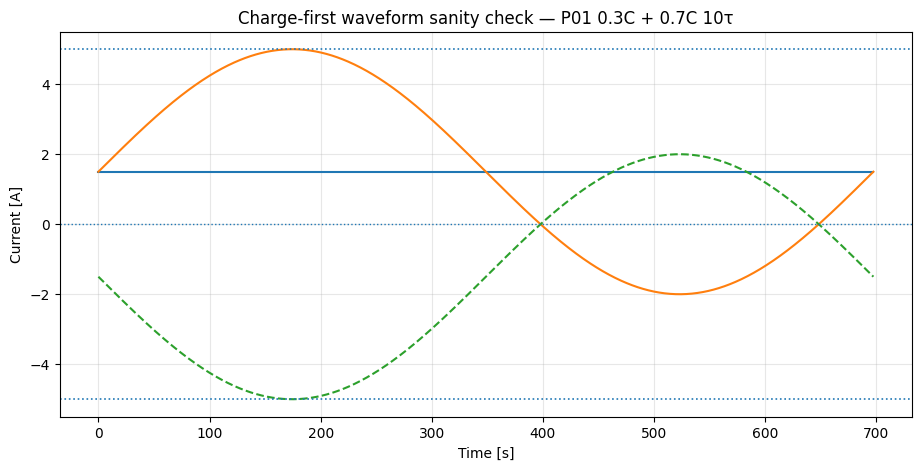

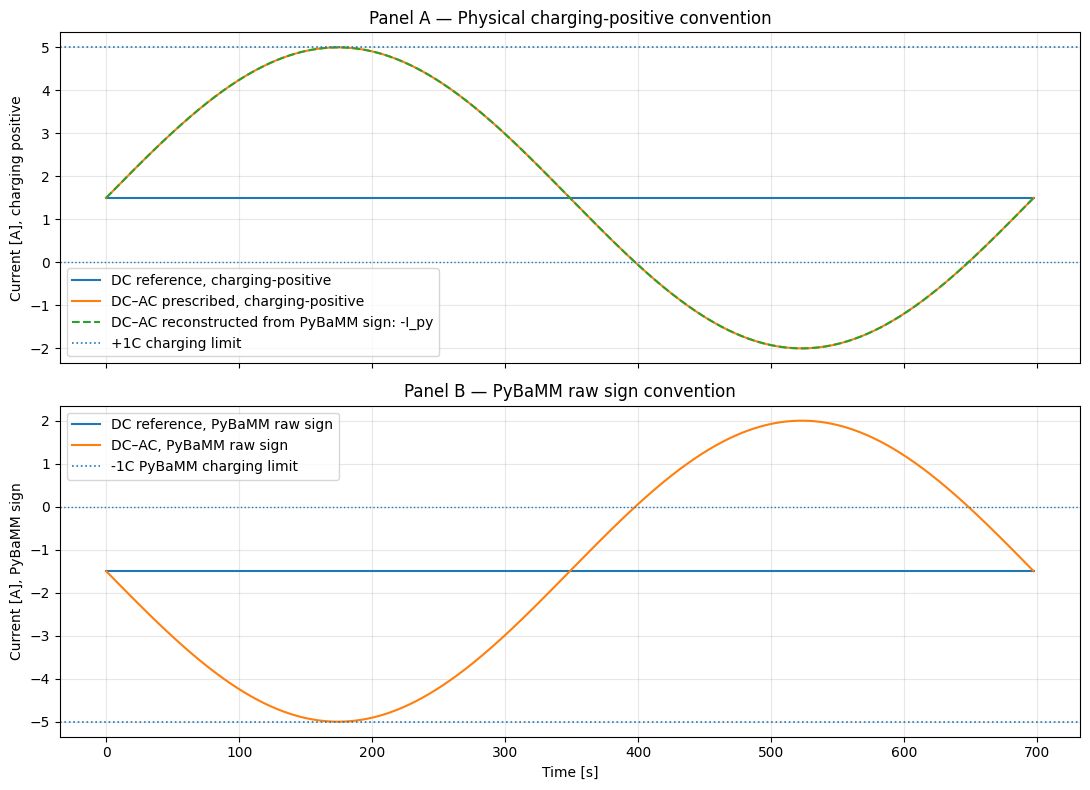

[OK] Charge-first current convention sanity plot passed with explicit sign reconstruction.
[OK] Charge-first current convention sanity plot passed.


In [6]:
# Cell 4 — Charge-first current convention sanity plot（charge-first 电流相位审计图）

def dc_current_chg_positive(t_s, dc_c, i_1c_a):
    """
    Charging-positive DC current in ampere.
    """
    return dc_c * i_1c_a * np.ones_like(np.asarray(t_s, dtype=float))


def dcac_current_chg_positive(t_s, dc_c, ac_c, frequency_hz, i_1c_a):
    """
    Charging-positive experimental/analysis convention:
        I_chg(t) = I_DC + I_AC * sin(2*pi*f*t)
    """
    t_s = np.asarray(t_s, dtype=float)
    i_dc = dc_c * i_1c_a
    i_ac = ac_c * i_1c_a
    return i_dc + i_ac * np.sin(2 * np.pi * frequency_hz * t_s)


def dcac_current_pybamm_sign(t_s, dc_c, ac_c, frequency_hz, i_1c_a):
    """
    PyBaMM convention: negative current charges the cell.
        I_py(t) = -I_DC - I_AC * sin(2*pi*f*t)
    """
    return -dcac_current_chg_positive(t_s, dc_c, ac_c, frequency_hz, i_1c_a)


# Use Chen2020 only for the visual current-amplitude basis.
plot_param = "Chen2020"
i_1c_plot = float(df_params.loc[df_params["parameter_set"] == plot_param, "I_1C_A"].iloc[0])

# Select one main case: 0.3C + 0.7C at 10tau
case = df_cfg.loc[df_cfg["pair_id"] == "P01_0p3DC_vs_0p3p0p7_10tau"].iloc[0].to_dict()

f = case["frequency_hz"]
period_s = 1.0 / f
t_plot = np.linspace(0, period_s, 1000)

i_dc_chg = dc_current_chg_positive(
    t_plot,
    dc_c=case["dc_ref_c"],
    i_1c_a=i_1c_plot,
)

i_dcac_chg = dcac_current_chg_positive(
    t_plot,
    dc_c=case["dcac_dc_c"],
    ac_c=case["dcac_ac_c"],
    frequency_hz=f,
    i_1c_a=i_1c_plot,
)

i_dcac_py = dcac_current_pybamm_sign(
    t_plot,
    dc_c=case["dcac_dc_c"],
    ac_c=case["dcac_ac_c"],
    frequency_hz=f,
    i_1c_a=i_1c_plot,
)

print("[sanity case]", case["pair_id"])
print("[parameter basis]", plot_param)
print("[I_1C_A]", i_1c_plot)
print("[frequency_hz]", f)
print("[period_s]", period_s)
print("[period_min]", period_s / 60)
print("[I_chg min/max A]", float(np.min(i_dcac_chg)), float(np.max(i_dcac_chg)))
print("[I_py min/max A]", float(np.min(i_dcac_py)), float(np.max(i_dcac_py)))

# Key audit assertions
assert np.isclose(np.max(i_dcac_chg), i_1c_plot, rtol=1e-3, atol=1e-6), "Peak charging current should be 1C"
assert np.isclose(np.min(i_dcac_chg), -0.4 * i_1c_plot, rtol=1e-3, atol=1e-6), "0.3C+0.7C should dip to -0.4C in charging-positive convention"
assert i_dcac_chg[1] > i_dcac_chg[0], "Charge-first convention failed: first half-wave should initially increase charging current"
assert i_dcac_py[1] < i_dcac_py[0], "PyBaMM current should become more negative at charge-first start"

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(t_plot, i_dc_chg, label="DC reference, charging-positive")
ax.plot(t_plot, i_dcac_chg, label="DC–AC, charging-positive")
ax.plot(t_plot, i_dcac_py, linestyle="--", label="DC–AC, PyBaMM sign")

ax.axhline(i_1c_plot, linestyle=":", linewidth=1.2, label="+1C charging limit")
ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.axhline(-i_1c_plot, linestyle=":", linewidth=1.2, label="-1C PyBaMM charge direction")

ax.set_title("Charge-first waveform sanity check — P01 0.3C + 0.7C 10τ")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Current [A]")
ax.grid(True, alpha=0.3)# Cell 4 — Charge-first current convention sanity plot（charge-first 电流相位审计图，修正版）

def dc_current_chg_positive(t_s, dc_c, i_1c_a):
    """
    Charging-positive DC current in ampere.
    """
    return dc_c * i_1c_a * np.ones_like(np.asarray(t_s, dtype=float))


def dcac_current_chg_positive(t_s, dc_c, ac_c, frequency_hz, i_1c_a):
    """
    Charging-positive experimental/analysis convention:
        I_chg(t) = I_DC + I_AC * sin(2*pi*f*t)
    """
    t_s = np.asarray(t_s, dtype=float)
    i_dc = dc_c * i_1c_a
    i_ac = ac_c * i_1c_a
    return i_dc + i_ac * np.sin(2 * np.pi * frequency_hz * t_s)


def dc_current_pybamm_sign(t_s, dc_c, i_1c_a):
    """
    PyBaMM convention:
        negative current charges the cell.
    """
    return -dc_current_chg_positive(t_s, dc_c, i_1c_a)


def dcac_current_pybamm_sign(t_s, dc_c, ac_c, frequency_hz, i_1c_a):
    """
    PyBaMM convention:
        I_py(t) = -I_DC - I_AC * sin(2*pi*f*t)
    """
    return -dcac_current_chg_positive(t_s, dc_c, ac_c, frequency_hz, i_1c_a)


# Use Chen2020 only for visual current-amplitude basis.
plot_param = "Chen2020"
i_1c_plot = float(df_params.loc[df_params["parameter_set"] == plot_param, "I_1C_A"].iloc[0])

# Select one main case: 0.3C + 0.7C at 10tau
case = df_cfg.loc[df_cfg["pair_id"] == "P01_0p3DC_vs_0p3p0p7_10tau"].iloc[0].to_dict()

f = case["frequency_hz"]
period_s = 1.0 / f
t_plot = np.linspace(0, period_s, 1000)

# Charging-positive convention
i_dc_chg = dc_current_chg_positive(
    t_plot,
    dc_c=case["dc_ref_c"],
    i_1c_a=i_1c_plot,
)

i_dcac_chg = dcac_current_chg_positive(
    t_plot,
    dc_c=case["dcac_dc_c"],
    ac_c=case["dcac_ac_c"],
    frequency_hz=f,
    i_1c_a=i_1c_plot,
)

# PyBaMM raw sign convention
i_dc_py = dc_current_pybamm_sign(
    t_plot,
    dc_c=case["dc_ref_c"],
    i_1c_a=i_1c_plot,
)

i_dcac_py = dcac_current_pybamm_sign(
    t_plot,
    dc_c=case["dcac_dc_c"],
    ac_c=case["dcac_ac_c"],
    frequency_hz=f,
    i_1c_a=i_1c_plot,
)

# Reconstructed charging-positive current from PyBaMM sign
i_dcac_chg_from_py = -i_dcac_py
i_dc_chg_from_py = -i_dc_py

print("[sanity case]", case["pair_id"])
print("[parameter basis]", plot_param)
print("[I_1C_A]", i_1c_plot)
print("[frequency_hz]", f)
print("[period_s]", period_s)
print("[period_min]", period_s / 60)
print("[I_chg min/max A]", float(np.min(i_dcac_chg)), float(np.max(i_dcac_chg)))
print("[I_py min/max A]", float(np.min(i_dcac_py)), float(np.max(i_dcac_py)))

# Audit assertions
assert np.isclose(i_dcac_chg[0], case["dcac_dc_c"] * i_1c_plot, rtol=1e-12, atol=1e-12)
assert np.isclose(i_dcac_py[0], -case["dcac_dc_c"] * i_1c_plot, rtol=1e-12, atol=1e-12)

assert np.isclose(
    np.max(i_dcac_chg),
    i_1c_plot,
    rtol=1e-3,
    atol=1e-6,
), "Peak charging-positive current should be +1C"

assert np.isclose(
    np.min(i_dcac_chg),
    -0.4 * i_1c_plot,
    rtol=1e-3,
    atol=1e-6,
), "0.3C+0.7C should dip to -0.4C in charging-positive convention"

assert i_dcac_chg[1] > i_dcac_chg[0], (
    "Charge-first convention failed: first half-wave should initially increase charging current"
)

assert i_dcac_py[1] < i_dcac_py[0], (
    "PyBaMM current should become more negative at charge-first start"
)

assert np.allclose(
    i_dcac_chg_from_py,
    i_dcac_chg,
    rtol=1e-12,
    atol=1e-12,
), "Reconstructed charging-positive current from PyBaMM sign does not match prescribed DCAC"

assert np.allclose(
    i_dc_chg_from_py,
    i_dc_chg,
    rtol=1e-12,
    atol=1e-12,
), "Reconstructed charging-positive DC current from PyBaMM sign does not match prescribed DC"

max_reconstruction_error = float(np.max(np.abs(i_dcac_chg_from_py - i_dcac_chg)))
print("[max |(-I_py) - I_chg| A]", max_reconstruction_error)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Panel 1: charging-positive physical convention
axes[0].plot(t_plot, i_dc_chg, label="DC reference, charging-positive")
axes[0].plot(t_plot, i_dcac_chg, label="DC–AC prescribed, charging-positive")
axes[0].plot(
    t_plot,
    i_dcac_chg_from_py,
    linestyle="--",
    label="DC–AC reconstructed from PyBaMM sign: -I_py",
)

axes[0].axhline(i_1c_plot, linestyle=":", linewidth=1.2, label="+1C charging limit")
axes[0].axhline(0.0, linestyle=":", linewidth=1.0)
axes[0].set_title("Panel A — Physical charging-positive convention")
axes[0].set_ylabel("Current [A], charging positive")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

# Panel 2: raw PyBaMM convention
axes[1].plot(t_plot, i_dc_py, label="DC reference, PyBaMM raw sign")
axes[1].plot(t_plot, i_dcac_py, label="DC–AC, PyBaMM raw sign")
axes[1].axhline(-i_1c_plot, linestyle=":", linewidth=1.2, label="-1C PyBaMM charging limit")
axes[1].axhline(0.0, linestyle=":", linewidth=1.0)
axes[1].set_title("Panel B — PyBaMM raw sign convention")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Current [A], PyBaMM sign")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

print("[OK] Charge-first current convention sanity plot passed with explicit sign reconstruction.")
ax.legend(loc="best")
plt.show()

print("[OK] Charge-first current convention sanity plot passed.")

[smoke parameter set] Chen2020
[smoke case] P01_0p3DC_vs_0p3p0p7_10tau


,parameter_set,protocol_label,dc_c,ac_c,frequency_hz,initial_soc,Q_nom_Ah,I_1C_A,t_stop_s,t_stop_min,V_stop_V,Q_stop_Ah,Q_stop_frac_nominal,I_chg_last_A,termination,status,error_msg
0,Chen2020,DC_ref_CC_to_Vmax,0.3,0.0,0.001434,0.05,5.0,5.0,10782.817059,179.713618,4.19999,4.492840,0.898568,1.500000,event: Maximum voltage [V],ok,
1,Chen2020,DCAC_CC_to_Vmax,0.3,0.7,0.001434,0.05,5.0,5.0,10494.543245,174.909054,4.19999,4.377472,0.875494,2.526477,event: Maximum voltage [V],ok,


[expected DCAC I_chg(0) A] 1.5
[observed DCAC I_chg(0) A] 1.5


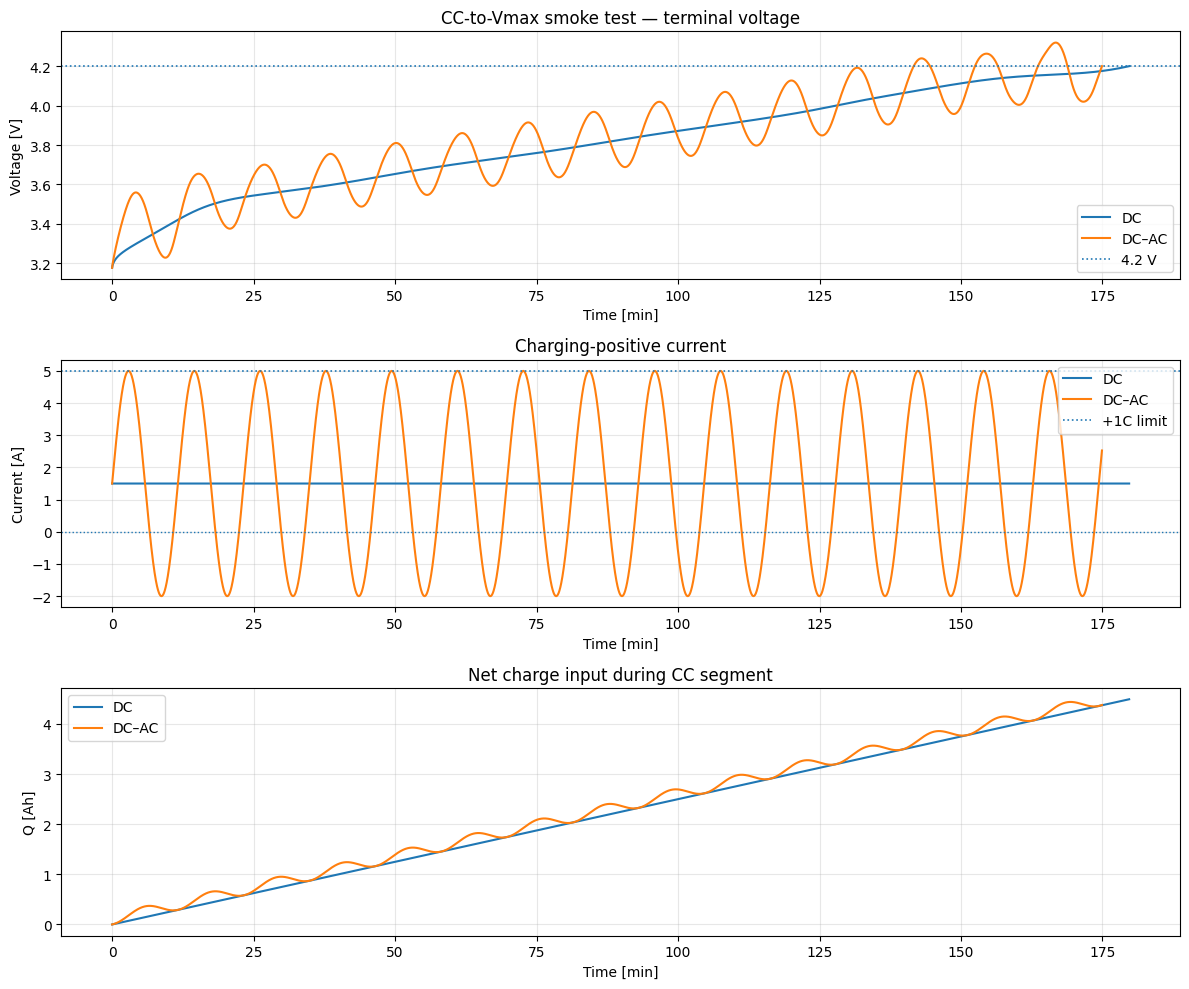

[OK] CC-to-Vmax smoke test completed.


In [9]:
# Cell 5 — Current-controlled CC-to-Vmax smoke test（电流控制CC段到4.2V冒烟测试）

def cumtrapz_np(y, x):
    """
    Minimal cumulative trapezoidal integration without scipy dependency.
    Returns integral array with the same length as x.
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    if len(x) < 2:
        return out
    dx = np.diff(x)
    avg_y = 0.5 * (y[1:] + y[:-1])
    out[1:] = np.cumsum(avg_y * dx)
    return out


def make_pybamm_current_function(dc_c, ac_c, frequency_hz, i_1c_a):
    """
    Return a PyBaMM-compatible callable current function.

    PyBaMM sign convention:
        positive current = discharge
        negative current = charge

    Charge-first experimental convention:
        I_chg(t) = I_DC + I_AC * sin(2*pi*f*t)

    Therefore:
        I_py(t) = -I_chg(t)
                = -I_DC - I_AC * sin(2*pi*f*t)
    """
    i_dc = float(dc_c) * float(i_1c_a)
    i_ac = float(ac_c) * float(i_1c_a)
    f = float(frequency_hz)

    def current_fun(t):
        return -i_dc - i_ac * pybamm.sin(2 * math.pi * f * t)

    return current_fun


def run_cc_to_vmax(
    parameter_set,
    protocol_label,
    dc_c,
    ac_c,
    frequency_hz,
    initial_soc=0.05,
    t_max_s=8 * 3600,
    dt_out_s=2.0,
):
    """
    Run a current-controlled PyBaMM DFN simulation until the model voltage event stops it.
    This is only the AC-on/DC current-controlled CC segment.

    Returns:
        summary dict,
        trajectory dataframe,
        PyBaMM solution
    """
    pv_base = PARAM_VALUES[parameter_set]
    pv = pv_base.copy()

    q_nom_ah = float(pv["Nominal cell capacity [A.h]"])
    i_1c_a = q_nom_ah

    current_fun = make_pybamm_current_function(
        dc_c=dc_c,
        ac_c=ac_c,
        frequency_hz=frequency_hz,
        i_1c_a=i_1c_a,
    )

    pv.update({"Current function [A]": current_fun})

    model = pybamm.lithium_ion.DFN()

    solver = pybamm.CasadiSolver(
        mode="safe",
        rtol=1e-6,
        atol=1e-8,
    )

    t_eval = np.arange(0, t_max_s + dt_out_s, dt_out_s)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        solver=solver,
    )

    try:
        sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
        status = "ok"
        error_msg = ""
    except Exception as e:
        return (
            {
                "parameter_set": parameter_set,
                "protocol_label": protocol_label,
                "dc_c": dc_c,
                "ac_c": ac_c,
                "frequency_hz": frequency_hz,
                "initial_soc": initial_soc,
                "status": "failed",
                "error_msg": repr(e),
            },
            pd.DataFrame(),
            None,
        )

    t_s = np.asarray(sol.t, dtype=float)

    # Processed variables at solution time grid
    V = np.asarray(sol["Terminal voltage [V]"](t_s), dtype=float).reshape(-1)
    I_py = np.asarray(sol["Current [A]"](t_s), dtype=float).reshape(-1)

    # Charging-positive current
    I_chg = -I_py

    # Net charge input in Ah
    Q_Ah = cumtrapz_np(I_chg, t_s) / 3600.0

    df = pd.DataFrame({
        "parameter_set": parameter_set,
        "protocol_label": protocol_label,
        "t_s": t_s,
        "t_min": t_s / 60.0,
        "V_terminal_V": V,
        "I_py_A": I_py,
        "I_chg_A": I_chg,
        "Q_Ah": Q_Ah,
        "Q_frac_nominal": Q_Ah / q_nom_ah,
    })

    summary = {
        "parameter_set": parameter_set,
        "protocol_label": protocol_label,
        "dc_c": dc_c,
        "ac_c": ac_c,
        "frequency_hz": frequency_hz,
        "initial_soc": initial_soc,
        "Q_nom_Ah": q_nom_ah,
        "I_1C_A": i_1c_a,
        "t_stop_s": float(t_s[-1]),
        "t_stop_min": float(t_s[-1] / 60.0),
        "V_stop_V": float(V[-1]),
        "Q_stop_Ah": float(Q_Ah[-1]),
        "Q_stop_frac_nominal": float(Q_Ah[-1] / q_nom_ah),
        "I_chg_last_A": float(I_chg[-1]),
        "termination": str(getattr(sol, "termination", "")),
        "status": status,
        "error_msg": error_msg,
    }

    return summary, df, sol


# Smoke-test case: Chen2020, P01 0.3C DC vs 0.3C+0.7C 10tau
smoke_param = "Chen2020"
smoke_case = df_cfg.loc[df_cfg["pair_id"] == "P01_0p3DC_vs_0p3p0p7_10tau"].iloc[0].to_dict()

print("[smoke parameter set]", smoke_param)
print("[smoke case]", smoke_case["pair_id"])

summary_dc, df_dc_cc, sol_dc_cc = run_cc_to_vmax(
    parameter_set=smoke_param,
    protocol_label="DC_ref_CC_to_Vmax",
    dc_c=smoke_case["dc_ref_c"],
    ac_c=0.0,
    frequency_hz=smoke_case["frequency_hz"],
    initial_soc=0.05,
    t_max_s=8 * 3600,
    dt_out_s=2.0,
)

summary_dcac, df_dcac_cc, sol_dcac_cc = run_cc_to_vmax(
    parameter_set=smoke_param,
    protocol_label="DCAC_CC_to_Vmax",
    dc_c=smoke_case["dcac_dc_c"],
    ac_c=smoke_case["dcac_ac_c"],
    frequency_hz=smoke_case["frequency_hz"],
    initial_soc=0.05,
    t_max_s=8 * 3600,
    dt_out_s=2.0,
)

df_smoke_summary = pd.DataFrame([summary_dc, summary_dcac])
display(df_smoke_summary)

assert summary_dc["status"] == "ok", summary_dc["error_msg"]
assert summary_dcac["status"] == "ok", summary_dcac["error_msg"]

# Basic voltage event plausibility
assert summary_dc["V_stop_V"] >= 4.19, "DC branch did not reach upper voltage region."
assert summary_dcac["V_stop_V"] >= 4.19, "DCAC branch did not reach upper voltage region."

# Current reconstruction sanity: DCAC initial charging current should start at DC level
i_1c_smoke = summary_dcac["I_1C_A"]
expected_i0 = smoke_case["dcac_dc_c"] * i_1c_smoke
observed_i0 = float(df_dcac_cc["I_chg_A"].iloc[0])
print("[expected DCAC I_chg(0) A]", expected_i0)
print("[observed DCAC I_chg(0) A]", observed_i0)
assert np.isclose(observed_i0, expected_i0, rtol=1e-5, atol=1e-6)

# Plot audit
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

axes[0].plot(df_dc_cc["t_min"], df_dc_cc["V_terminal_V"], label="DC")
axes[0].plot(df_dcac_cc["t_min"], df_dcac_cc["V_terminal_V"], label="DC–AC")
axes[0].axhline(4.2, linestyle=":", linewidth=1.2, label="4.2 V")
axes[0].set_title("CC-to-Vmax smoke test — terminal voltage")
axes[0].set_xlabel("Time [min]")
axes[0].set_ylabel("Voltage [V]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

axes[1].plot(df_dc_cc["t_min"], df_dc_cc["I_chg_A"], label="DC")
axes[1].plot(df_dcac_cc["t_min"], df_dcac_cc["I_chg_A"], label="DC–AC")
axes[1].axhline(i_1c_smoke, linestyle=":", linewidth=1.2, label="+1C limit")
axes[1].axhline(0.0, linestyle=":", linewidth=1.0)
axes[1].set_title("Charging-positive current")
axes[1].set_xlabel("Time [min]")
axes[1].set_ylabel("Current [A]")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

axes[2].plot(df_dc_cc["t_min"], df_dc_cc["Q_Ah"], label="DC")
axes[2].plot(df_dcac_cc["t_min"], df_dcac_cc["Q_Ah"], label="DC–AC")
axes[2].set_title("Net charge input during CC segment")
axes[2].set_xlabel("Time [min]")
axes[2].set_ylabel("Q [Ah]")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="best")

plt.tight_layout()
plt.show()

print("[OK] CC-to-Vmax smoke test completed.")